# Comprehensive Road Scene Understanding — Anomaly Segmentation
End-to-end notebook: setup, ERFNet pixel baselines (Step 7), EoMT mask baselines for
Cityscapes & COCO checkpoints (Step 8), temperature scaling, and the two-model
Cityscapes comparison with the MSeg COCO→Cityscapes mapping (Step 4).

**Run top to bottom. Requires a GPU runtime (Runtime → Change runtime type → T4 GPU).**


## 0. Setup: GPU check, clone repo, install deps
*Note: we deliberately do NOT install `ood-metrics` — it pins numpy<2 and breaks scipy. We define `fpr_at_95_tpr` ourselves.*

In [ ]:
import torch
print("CUDA:", torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU")
assert torch.cuda.is_available(), "Enable GPU: Runtime -> Change runtime type -> T4 GPU"
%cd /content
import os
if not os.path.exists("/content/MaskArchitectureAnomaly_CourseProject"):
    !git clone -q https://github.com/AlessandroMarinai/MaskArchitectureAnomaly_CourseProject.git
!pip install -q gdown timm lightning
import numpy as np, cv2
print("numpy", np.__version__, "| cv2", cv2.__version__)

CUDA: True NVIDIA A100-SXM4-40GB
/content
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 57.5 MB/s eta 0:00:00
numpy 2.0.2 | cv2 4.13.0


## 1. Assets: EoMT checkpoints + anomaly validation datasets

In [ ]:
import os
ASSETS="/content/assets"; os.makedirs(ASSETS, exist_ok=True)
REPO="/content/MaskArchitectureAnomaly_CourseProject"
if not os.path.exists(f"{ASSETS}/eomt_cityscapes.bin"):
    !gdown --folder "https://drive.google.com/drive/folders/1q2vHUzora2nP52fP50zmoQAykWuwoGav" -O {ASSETS}/drive_folder
    !cp {ASSETS}/drive_folder/*.bin {ASSETS}/
    !cp {ASSETS}/drive_folder/Anomaly_Validation_Datasets.zip {ASSETS}/
!ln -sf {ASSETS} {REPO}/eomt_ckpt
!mkdir -p {REPO}/datasets
!unzip -q -o {ASSETS}/Anomaly_Validation_Datasets.zip -d {REPO}/datasets/
!ls -lh {ASSETS}/*.bin
!find {REPO}/datasets/Validation_Dataset -maxdepth 1 -type d

Retrieving folder contents
Retrieving folder 11uyQc6M8xDTGji1bltehx0wlylqA4isf Project Descriptions
Processing file 1tq5F_j_8O2vlGWbkU1ayPjYvCml1VEwr ComprehensiveRoadScenesUnderstanding.pdf
Processing file 1Vz08DHsP_mojpCTAQTR6NHVq-2rEqAZM MaskArchitectureAnomalySegmentation.pdf
Processing file 1zcayoIIJztxKuHOIjmSjGoQBDy4RdETr Anomaly_Validation_Datasets.zip
Processing file 1vSLNXzu3zCuJ7oeu_hSV7xVTJPUoXvH0 eomt_cityscapes.bin
Processing file 13tCjPYFBVf43hS9SqODsKqGeGx2TsgzS eomt_coco.bin
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1tq5F_j_8O2vlGWbkU1ayPjYvCml1VEwr
To: /content/assets/drive_folder/Project Descriptions/ComprehensiveRoadScenesUnderstanding.pdf
100% 329k/329k [00:00<00:00, 157MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Vz08DHsP_mojpCTAQTR6NHVq-2rEqAZM
To: /content/assets/drive_folder/Project Descriptions/MaskArchitectureAnomalySegmentation.pdf

## 2. (Steps 4 & 5) Cityscapes — needed for mIoU / two-model comparison / fine-tuning
*~11 GB; first run only. Skip this cell if you only want the anomaly baselines (Steps 7–8).*

In [ ]:
import os, getpass
CS="/content/cityscapes"; os.makedirs(CS, exist_ok=True)
if not os.path.exists(f"{CS}/leftImg8bit_trainvaltest.zip"):
    %cd $CS
    user=input("Cityscapes username: "); pw=getpass.getpass("password: ")
    !wget -q --keep-session-cookies --save-cookies=cookies.txt --post-data "username={user}&password={pw}&submit=Login" https://www.cityscapes-dataset.com/login/ -O /dev/null
    !wget --content-disposition --load-cookies cookies.txt "https://www.cityscapes-dataset.com/file-handling/?packageID=1"
    !wget --content-disposition --load-cookies cookies.txt "https://www.cityscapes-dataset.com/file-handling/?packageID=3"
    %cd /content/MaskArchitectureAnomaly_CourseProject
!ls -lh {CS}/*.zip

/content/cityscapes
Cityscapes username: Eghbal1992
password: ··········
--2026-06-07 17:35:39--  https://www.cityscapes-dataset.com/file-handling/?packageID=1
Resolving www.cityscapes-dataset.com (www.cityscapes-dataset.com)... 139.19.217.8
Connecting to www.cityscapes-dataset.com (www.cityscapes-dataset.com)|139.19.217.8|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 252567705 (241M) [application/octet-stream]
Saving to: ‘gtFine_trainvaltest.zip’

gtFine_trainvaltest 100%[===================>] 240.87M  20.1MB/s    in 13s     

2026-06-07 17:35:53 (19.0 MB/s) - ‘gtFine_trainvaltest.zip’ saved [252567705/252567705]

--2026-06-07 17:35:53--  https://www.cityscapes-dataset.com/file-handling/?packageID=3
Resolving www.cityscapes-dataset.com (www.cityscapes-dataset.com)... 139.19.217.8
Connecting to www.cityscapes-dataset.com (www.cityscapes-dataset.com)|139.19.217.8|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11592327197 (11G) [appl

## 3. (Step 7) ERFNet pixel baselines —  the corrected eval script
Fixes applied to the starter `evalAnomaly.py`:
1. removed the `images.permute(0,3,1,2)` bug (corrupted tensor dims → conv crash);
2. dropped `ood_metrics` (forces numpy<2) → local `fpr_at_95_tpr`;
3. added `--method {msp,maxlogit,maxentropy}` + `--temperature` (true softmax-MSP, raw-logit MaxLogit, normalized entropy).

In [ ]:
%%writefile /content/MaskArchitectureAnomaly_CourseProject/eval/evalAnomaly.py
import os, glob, torch, random
import numpy as np
from PIL import Image
import torch.nn.functional as F
from erfnet import ERFNet
from argparse import ArgumentParser
from sklearn.metrics import roc_curve, average_precision_score
from torchvision.transforms import Compose, Resize, ToTensor

seed=42; random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
NUM_CLASSES=20
torch.backends.cudnn.deterministic=True

def fpr_at_95_tpr(scores, labels):
    fpr,tpr,_=roc_curve(labels,scores); return float(np.interp(0.95,tpr,fpr))

input_transform=Compose([Resize((512,1024),Image.BILINEAR),ToTensor()])
target_transform=Compose([Resize((512,1024),Image.NEAREST)])

def main():
    p=ArgumentParser()
    p.add_argument("--input",nargs="+",required=True)
    p.add_argument('--loadDir',default="../trained_models/")
    p.add_argument('--loadWeights',default="erfnet_pretrained.pth")
    p.add_argument('--method',default="maxlogit",choices=["msp","maxlogit","maxentropy"])
    p.add_argument('--temperature',type=float,default=1.0)
    p.add_argument('--cpu',action='store_true')
    args=p.parse_args()
    weightspath=args.loadDir+args.loadWeights
    model=ERFNet(NUM_CLASSES)
    if not args.cpu: model=torch.nn.DataParallel(model).cuda()
    def load_my_state_dict(model,state_dict):
        own=model.state_dict()
        for name,param in state_dict.items():
            if name not in own:
                if name.startswith("module."): own[name.split("module.")[-1]].copy_(param)
                else: continue
            else: own[name].copy_(param)
        return model
    model=load_my_state_dict(model,torch.load(weightspath,map_location=lambda s,l:s)); model.eval()
    print("weights loaded")
    sl,gl=[],[]
    for path in glob.glob(os.path.expanduser(str(args.input[0]))):
        images=input_transform(Image.open(path).convert('RGB')).unsqueeze(0).float().cuda()
        with torch.no_grad(): result=model(images)
        logits=result.squeeze(0)
        if args.temperature!=1.0: logits=logits/args.temperature
        if args.method=="msp": a=1.0-F.softmax(logits,dim=0).max(0)[0]
        elif args.method=="maxlogit": a=-logits.max(0)[0]
        else:
            probs=F.softmax(logits,dim=0); logp=F.log_softmax(logits,dim=0)
            a=-(probs*logp).sum(0)/np.log(NUM_CLASSES)
        a=a.data.cpu().numpy()
        pathGT=path.replace("images","labels_masks")
        if "RoadObsticle21" in pathGT: pathGT=pathGT.replace("webp","png")
        if "fs_static" in pathGT: pathGT=pathGT.replace("jpg","png")
        if "RoadAnomaly" in pathGT: pathGT=pathGT.replace("jpg","png")
        g=np.array(target_transform(Image.open(pathGT)))
        if "RoadAnomaly" in pathGT: g=np.where(g==2,1,g)
        if 1 not in np.unique(g): continue
        gl.append(g); sl.append(a); del result; torch.cuda.empty_cache()
    g=np.array(gl); s=np.array(sl)
    vo=np.concatenate((s[g==0],s[g==1])); vl=np.concatenate((np.zeros((g==0).sum()),np.ones((g==1).sum())))
    print(f"AUPRC score: {average_precision_score(vl,vo)*100.0}")
    print(f"FPR@TPR95: {fpr_at_95_tpr(vo,vl)*100.0}")

if __name__=='__main__': main()

Overwriting /content/MaskArchitectureAnomaly_CourseProject/eval/evalAnomaly.py


### Run ERFNet: 3 methods × 5 datasets

In [ ]:
%cd /content/MaskArchitectureAnomaly_CourseProject/eval
import subprocess, re
base="../datasets/Validation_Dataset"
datasets={"RA-21":f"{base}/RoadAnomaly21/images/*.png","RO-21":f"{base}/RoadObsticle21/images/*.webp",
          "FS L&F":f"{base}/FS_LostFound_full/images/*.png","FS Static":f"{base}/fs_static/images/*.jpg",
          "RoadAnomaly":f"{base}/RoadAnomaly/images/*.jpg"}
methods=["msp","maxlogit","maxentropy"]; res={}
for m in methods:
    for n,gl in datasets.items():
        out=subprocess.run(["python","evalAnomaly.py","--method",m,"--input",gl],capture_output=True,text=True)
        t=out.stdout+out.stderr
        a=re.search(r"AUPRC score:\s*([\d.]+)",t); f=re.search(r"FPR@TPR95:\s*([\d.]+)",t)
        if a and f: res[(m,n)]=(float(a.group(1)),float(f.group(1))); print(f"{m:11s}{n:12s}{a.group(1):.6} {f.group(1):.6}")
        else: print(m,n,"FAILED"); print(t[-400:])
print("\n=== ERFNet ===\nmethod      | "+" | ".join(datasets))
for m in methods: print(f"{m:11s} | "+" | ".join(f"{res[(m,n)][0]:.1f}/{res[(m,n)][1]:.1f}" for n in datasets))

/content/MaskArchitectureAnomaly_CourseProject/eval
msp        RA-21       29.079 62.567
msp        RO-21       2.7131 65.281
msp        FS L&F      1.7483 50.659
msp        FS Static   7.4727 41.857
msp        RoadAnomaly 12.421 82.585
maxlogit   RA-21       38.291 59.373
maxlogit   RO-21       4.6316 48.463
maxlogit   FS L&F      3.3016 45.537
maxlogit   FS Static   9.4985 40.315
maxlogit   RoadAnomaly 15.581 73.279
maxentropy RA-21       30.953 62.674
maxentropy RO-21       3.0487 65.951
maxentropy FS L&F      2.5837 50.234
maxentropy FS Static   8.8379 41.566
maxentropy RoadAnomaly 12.667 82.757

=== ERFNet ===
method      | RA-21 | RO-21 | FS L&F | FS Static | RoadAnomaly
msp         | 29.1/62.6 | 2.7/65.3 | 1.7/50.7 | 7.5/41.9 | 12.4/82.6
maxlogit    | 38.3/59.4 | 4.6/48.5 | 3.3/45.5 | 9.5/40.3 | 15.6/73.3
maxentropy  | 31.0/62.7 | 3.0/66.0 | 2.6/50.2 | 8.8/41.6 | 12.7/82.8


## 4. (Step 8) EoMT mask baselines — write the EoMT eval module
Config-driven (works for both Cityscapes-19 and COCO-133 checkpoints). Computes the per-pixel
class map `P_c = Σ_q σ(mask_q)·softmax(cls_q)` then MSP / MaxLogit / MaxEntropy / RbA.

In [ ]:
%%writefile /content/MaskArchitectureAnomaly_CourseProject/eomt/evalAnomalyEoMT.py
import os, yaml, importlib, random
import numpy as np, torch
import torch.nn.functional as F
from torch.amp.autocast_mode import autocast
from sklearn.metrics import roc_curve, average_precision_score

seed=42; random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

def fpr_at_95_tpr(scores, labels):
    fpr,tpr,_=roc_curve(labels,scores); return float(np.interp(0.95,tpr,fpr))

def build_model(config_path, ckpt_path, device, num_classes, img_size=(1024,1024)):
    with open(config_path) as f: cfg=yaml.safe_load(f)
    enc=cfg["model"]["init_args"]["network"]["init_args"]["encoder"]
    m,c=enc["class_path"].rsplit(".",1)
    encoder=getattr(importlib.import_module(m),c)(img_size=img_size, **enc.get("init_args",{}))
    net=cfg["model"]["init_args"]["network"]; m,c=net["class_path"].rsplit(".",1)
    nk={k:v for k,v in net["init_args"].items() if k!="encoder"}
    network=getattr(importlib.import_module(m),c)(masked_attn_enabled=False, num_classes=num_classes, encoder=encoder, **nk)
    m,c=cfg["model"]["class_path"].rsplit(".",1)
    mk={k:v for k,v in cfg["model"]["init_args"].items() if k!="network"}
    _dia=cfg.get("data",{}).get("init_args",{})
    if "stuff_classes" in _dia: mk["stuff_classes"]=_dia["stuff_classes"]
    model=getattr(importlib.import_module(m),c)(img_size=img_size, num_classes=num_classes, network=network, **mk).eval().to(device)
    sd=torch.load(ckpt_path, map_location=device, weights_only=True)
    if isinstance(sd,dict) and "state_dict" in sd: sd=sd["state_dict"]
    miss,unexp=model.load_state_dict(sd, strict=False)
    print(f"loaded {os.path.basename(ckpt_path)} | missing={len(miss)} unexpected={len(unexp)}")
    return model

@torch.no_grad()
def pixel_logits(model, pil_img, device):
    arr=np.array(pil_img.convert("RGB"))
    img=torch.from_numpy(arr).permute(2,0,1).to(device)
    sizes=[img.shape[-2:]]
    crops,origins=model.window_imgs_semantic([img])
    with autocast(dtype=torch.float16, device_type="cuda"):
        ml,cl=model(crops); ml=F.interpolate(ml[-1], model.img_size, mode="bilinear")
        cropl=model.to_per_pixel_logits_semantic(ml, cl[-1])
    return model.revert_window_logits_semantic(cropl, origins, sizes)[0].float()

def anomaly_from_logits(P, method, T=1.0):
    K=P.shape[0]
    if method=="maxlogit": return -P.max(0).values
    if method=="rba":      return -P.tanh().sum(0)
    probs=(P/T).softmax(0)
    if method=="msp":        return 1.0 - probs.max(0).values
    if method=="maxentropy": return -(probs*probs.clamp_min(1e-12).log()).sum(0)/np.log(K)
    raise ValueError(method)

Writing /content/MaskArchitectureAnomaly_CourseProject/eomt/evalAnomalyEoMT.py


### Shared EoMT anomaly-eval loop (512×1024, float16 — avoids the FS L&F RAM-OOM)

In [ ]:
%cd /content/MaskArchitectureAnomaly_CourseProject/eomt
import glob, gc, numpy as np, torch, cv2
from PIL import Image
from importlib import reload
import evalAnomalyEoMT as M; reload(M)
from sklearn.metrics import average_precision_score

EH,EW=512,1024
base="../datasets/Validation_Dataset"
datasets={"RA-21":f"{base}/RoadAnomaly21/images/*.png","RO-21":f"{base}/RoadObsticle21/images/*.webp",
          "FS L&F":f"{base}/FS_LostFound_full/images/*.png","FS Static":f"{base}/fs_static/images/*.jpg",
          "RoadAnomaly":f"{base}/RoadAnomaly/images/*.jpg"}
def load_gt(path):
    g=path.replace("images","labels_masks")
    if "RoadObsticle21" in g: g=g.replace("webp","png")
    if "fs_static" in g: g=g.replace("jpg","png")
    if "RoadAnomaly" in g: g=g.replace("jpg","png")
    a=np.array(Image.open(g))
    if "RoadAnomaly" in g: a=np.where(a==2,1,a)
    return a

def run_eomt(model, methods=("msp","maxlogit","maxentropy","rba")):
    res={}
    for d,gl in datasets.items():
        acc={m:([],[]) for m in methods}
        for path in sorted(glob.glob(gl)):
            g=load_gt(path)
            if 1 not in np.unique(g): continue
            gs=cv2.resize(g,(EW,EH),interpolation=cv2.INTER_NEAREST); ood=gs==1; ind=gs==0
            P=M.pixel_logits(model, Image.open(path), "cuda")
            for m in methods:
                s=M.anomaly_from_logits(P,m).cpu().numpy()
                s=cv2.resize(s,(EW,EH),interpolation=cv2.INTER_LINEAR)
                acc[m][0].append(s[ood].astype(np.float16)); acc[m][1].append(s[ind].astype(np.float16))
            del P; torch.cuda.empty_cache()
        for m in methods:
            o=np.concatenate(acc[m][0]).astype(np.float32); i=np.concatenate(acc[m][1]).astype(np.float32)
            val=np.concatenate([i,o]); lab=np.concatenate([np.zeros(len(i)),np.ones(len(o))])
            res[(d,m)]=(average_precision_score(lab,val)*100, M.fpr_at_95_tpr(val,lab)*100)
            print(f"{d:11s} {m:11s} AuPRC={res[(d,m)][0]:6.2f} FPR95={res[(d,m)][1]:6.2f}")
        del acc; gc.collect()
    print("\nmethod      | "+" | ".join(datasets))
    for m in methods: print(f"{m:11s} | "+" | ".join(f"{res[(d,m)][0]:.1f}/{res[(d,m)][1]:.1f}" for d in datasets))
    return res

/content/MaskArchitectureAnomaly_CourseProject/eomt


### EoMT-Cityscapes baselines

In [ ]:
import gc, torch
try: del model
except: pass
torch.cuda.empty_cache(); gc.collect()
model=M.build_model("configs/dinov2/cityscapes/semantic/eomt_base_640.yaml",
                    "../eomt_ckpt/eomt_cityscapes.bin","cuda",num_classes=19,img_size=(1024,1024))
print("=== EoMT-Cityscapes ==="); res_cs=run_eomt(model)

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'network' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['network'])`.


loaded eomt_cityscapes.bin | missing=0 unexpected=0
=== EoMT-Cityscapes ===
RA-21       msp         AuPRC= 67.28 FPR95= 30.79
RA-21       maxlogit    AuPRC= 68.52 FPR95= 31.62
RA-21       maxentropy  AuPRC= 67.20 FPR95= 40.59
RA-21       rba         AuPRC= 63.69 FPR95= 96.02
RO-21       msp         AuPRC= 93.97 FPR95=  0.35
RO-21       maxlogit    AuPRC= 94.15 FPR95=  0.35
RO-21       maxentropy  AuPRC= 92.72 FPR95=  0.33
RO-21       rba         AuPRC= 93.43 FPR95=  0.41
FS L&F      msp         AuPRC= 18.78 FPR95= 12.81
FS L&F      maxlogit    AuPRC= 16.64 FPR95= 12.58
FS L&F      maxentropy  AuPRC= 13.95 FPR95= 13.63
FS L&F      rba         AuPRC= 16.74 FPR95=  8.99
FS Static   msp         AuPRC= 54.23 FPR95= 53.49
FS Static   maxlogit    AuPRC= 58.43 FPR95= 46.28
FS Static   maxentropy  AuPRC= 42.00 FPR95= 70.71
FS Static   rba         AuPRC= 60.43 FPR95= 73.89
RoadAnomaly msp         AuPRC= 71.77 FPR95= 15.56
RoadAnomaly maxlogit    AuPRC= 71.91 FPR95= 15.20
RoadAnomaly maxentropy  

### EoMT-COCO baselines

In [ ]:
import gc, torch
try: del model
except: pass
torch.cuda.empty_cache(); gc.collect()
model=M.build_model("configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml",
                    "../eomt_ckpt/eomt_coco.bin","cuda",num_classes=133,img_size=(640,640))
print("=== EoMT-COCO ==="); res_coco=run_eomt(model)

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'network' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['network'])`.


loaded eomt_coco.bin | missing=0 unexpected=0
=== EoMT-COCO ===
RA-21       msp         AuPRC= 38.93 FPR95= 77.37
RA-21       maxlogit    AuPRC= 39.45 FPR95= 77.01
RA-21       maxentropy  AuPRC= 38.56 FPR95= 68.52
RA-21       rba         AuPRC= 16.66 FPR95= 81.43
RO-21       msp         AuPRC=  2.98 FPR95= 99.98
RO-21       maxlogit    AuPRC=  3.15 FPR95= 99.98
RO-21       maxentropy  AuPRC=  4.32 FPR95= 99.98
RO-21       rba         AuPRC= 55.74 FPR95= 99.88
FS L&F      msp         AuPRC=  3.87 FPR95= 97.14
FS L&F      maxlogit    AuPRC=  3.93 FPR95= 97.14
FS L&F      maxentropy  AuPRC=  2.73 FPR95= 96.87
FS L&F      rba         AuPRC=  0.27 FPR95= 97.18
FS Static   msp         AuPRC=  4.85 FPR95= 99.48
FS Static   maxlogit    AuPRC=  4.75 FPR95= 99.46
FS Static   maxentropy  AuPRC=  3.76 FPR95= 99.32
FS Static   rba         AuPRC=  2.33 FPR95= 95.66
RoadAnomaly msp         AuPRC= 18.48 FPR95= 91.93
RoadAnomaly maxlogit    AuPRC= 19.08 FPR95= 91.63
RoadAnomaly maxentropy  AuPRC= 18.61

## 5. Temperature scaling (EoMT-Cityscapes MSP, sweep T)

In [ ]:
import gc, torch, numpy as np, cv2, glob
from PIL import Image
try: del model
except: pass
torch.cuda.empty_cache(); gc.collect()
model=M.build_model("configs/dinov2/cityscapes/semantic/eomt_base_640.yaml",
                    "../eomt_ckpt/eomt_cityscapes.bin","cuda",num_classes=19,img_size=(1024,1024))
EH,EW=512,1024; temps=[0.5,0.75,1.0,1.1,1.25,1.5,2.0]; res={}
for d,gl in datasets.items():
    acc={t:([],[]) for t in temps}
    for path in sorted(glob.glob(gl)):
        g=load_gt(path)
        if 1 not in np.unique(g): continue
        gs=cv2.resize(g,(EW,EH),interpolation=cv2.INTER_NEAREST); ood=gs==1; ind=gs==0
        P=M.pixel_logits(model, Image.open(path), "cuda")
        for t in temps:
            s=M.anomaly_from_logits(P,"msp",t).cpu().numpy(); s=cv2.resize(s,(EW,EH))
            acc[t][0].append(s[ood].astype(np.float16)); acc[t][1].append(s[ind].astype(np.float16))
        del P; torch.cuda.empty_cache()
    for t in temps:
        o=np.concatenate(acc[t][0]).astype(np.float32); i=np.concatenate(acc[t][1]).astype(np.float32)
        val=np.concatenate([i,o]); lab=np.concatenate([np.zeros(len(i)),np.ones(len(o))])
        res[(d,t)]=(average_precision_score(lab,val)*100, M.fpr_at_95_tpr(val,lab)*100)
    gc.collect()
meanap={t:np.mean([res[(d,t)][0] for d in datasets]) for t in temps}; best=max(meanap,key=meanap.get)
print("mean AuPRC by t:",{t:round(v,1) for t,v in meanap.items()},"| best t =",best,"\n")
print("row              | "+" | ".join(datasets))
for t,l in [(1.0,"MSP"),(0.5,"MSP(t=0.5)"),(0.75,"MSP(t=0.75)"),(1.1,"MSP(t=1.1)"),(best,f"MSP(best={best})")]:
    print(f"{l:16s} | "+" | ".join(f"{res[(d,t)][0]:.1f}/{res[(d,t)][1]:.1f}" for d in datasets))

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'network' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['network'])`.


loaded eomt_cityscapes.bin | missing=0 unexpected=0
mean AuPRC by t: {0.5: np.float64(61.7), 0.75: np.float64(61.3), 1.0: np.float64(61.2), 1.1: np.float64(61.1), 1.25: np.float64(60.4), 1.5: np.float64(59.7), 2.0: np.float64(59.4)} | best t = 0.5 

row              | RA-21 | RO-21 | FS L&F | FS Static | RoadAnomaly
MSP              | 67.3/30.8 | 94.0/0.4 | 18.8/12.8 | 54.2/53.5 | 71.8/15.6
MSP(t=0.5)       | 68.0/30.2 | 94.0/0.4 | 18.6/12.8 | 55.6/50.2 | 72.2/15.8
MSP(t=0.75)      | 67.6/30.4 | 94.0/0.4 | 18.7/12.8 | 54.2/61.7 | 71.9/15.6
MSP(t=1.1)       | 67.2/32.0 | 94.0/0.3 | 18.8/12.8 | 53.9/65.7 | 71.6/15.6
MSP(best=0.5)    | 68.0/30.2 | 94.0/0.4 | 18.6/12.8 | 55.6/50.2 | 72.2/15.8


## 6. (Step 4) Two-model semantic comparison on Cityscapes val
COCO→Cityscapes mapping from the **MSeg** master taxonomy (only `pole` & `rider` unmappable).
Requires the Cityscapes download (cell 2).

In [ ]:
%cd /content/MaskArchitectureAnomaly_CourseProject/eomt
import yaml, importlib, numpy as np, torch, gc
import torch.nn.functional as F
from torch.amp.autocast_mode import autocast
from datasets.coco_panoptic import CLASS_MAPPING

csmap={1:11,2:18,3:13,4:17,6:15,7:16,8:14,10:6,13:7,119:8,128:2,148:0,151:2,154:9,
       171:3,175:3,176:3,177:3,184:8,185:4,187:10,191:1,193:9,194:9,197:2,199:3}
coco2cs=np.full(133,19,dtype=np.int64)
for catid,idx in CLASS_MAPPING.items():
    if catid in csmap: coco2cs[idx]=csmap[catid]
CS_NAMES=['road','sidewalk','building','wall','fence','pole','traffic light','traffic sign',
          'vegetation','terrain','sky','person','rider','car','truck','bus','train','motorcycle','bicycle']
SHARED=[i for i in range(19) if i not in (5,12)]

cfg=yaml.safe_load(open("configs/dinov2/cityscapes/semantic/eomt_base_640.yaml"))
mod,cls=cfg["data"]["class_path"].rsplit(".",1)
data=getattr(importlib.import_module(mod),cls)(path="/content/cityscapes", batch_size=1,
        num_workers=2, check_empty_targets=False, **cfg["data"].get("init_args",{})).setup()
ds=data.cityscapes_val_dataset; print("val images:", len(ds))

@torch.no_grad()
def infer_idx(model, img):
    crops,origins=model.window_imgs_semantic([img.to("cuda")])
    with autocast(dtype=torch.float16, device_type="cuda"):
        ml,cl=model(crops); ml=F.interpolate(ml[-1], model.img_size, mode="bilinear")
        cropl=model.to_per_pixel_logits_semantic(ml, cl[-1])
    return model.revert_window_logits_semantic(cropl, origins, [img.shape[-2:]])[0].argmax(0).cpu().numpy()

def eval_miou(model, remap=None, tag=""):
    conf=np.zeros((19,20),dtype=np.int64)
    for i in range(len(ds)):
        img,target=ds[i]; pred=infer_idx(model,img)
        if remap is not None: pred=remap[pred]
        gt=model.to_per_pixel_targets_semantic([target],255)[0].numpy(); v=gt!=255
        conf+=np.bincount(gt[v]*20+pred[v], minlength=380).reshape(19,20)
        if (i+1)%100==0: print(f"  {tag} {i+1}/{len(ds)}")
    tp=np.diag(conf[:,:19]); fn=conf.sum(1)-tp; fp=conf[:,:19].sum(0)-tp
    return tp/(tp+fp+fn+1e-9)

try: del model
except: pass
torch.cuda.empty_cache(); gc.collect()
csm=M.build_model("configs/dinov2/cityscapes/semantic/eomt_base_640.yaml",
                  "../eomt_ckpt/eomt_cityscapes.bin","cuda",num_classes=19,img_size=(1024,1024))
iou_cs=eval_miou(csm, None, "CS"); del csm; torch.cuda.empty_cache(); gc.collect()
cm=M.build_model("configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml",
                 "../eomt_ckpt/eomt_coco.bin","cuda",num_classes=133,img_size=(640,640))
iou_coco=eval_miou(cm, coco2cs, "COCO"); del cm; torch.cuda.empty_cache(); gc.collect()

print("\nclass            CS     COCO")
for n,a,b in zip(CS_NAMES, iou_cs, iou_coco): print(f"  {n:14s}{a*100:5.1f} {b*100:6.1f}")
print(f"\nmIoU(19)         CS={np.mean(iou_cs)*100:.2f}   COCO={np.mean(iou_coco)*100:.2f}")
print(f"mIoU(17 shared)  CS={np.mean(iou_cs[SHARED])*100:.2f}   COCO={np.mean(iou_coco[SHARED])*100:.2f}")

/content/MaskArchitectureAnomaly_CourseProject/eomt
val images: 500


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'network' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['network'])`.


loaded eomt_cityscapes.bin | missing=0 unexpected=0
  CS 100/500
  CS 200/500
  CS 300/500
  CS 400/500
  CS 500/500
loaded eomt_coco.bin | missing=0 unexpected=0
  COCO 100/500
  COCO 200/500
  COCO 300/500
  COCO 400/500
  COCO 500/500

class            CS     COCO
  road           98.4    0.0
  sidewalk       87.4   64.7
  building       94.1   84.7
  wall           66.1   45.8
  fence          65.5   48.1
  pole           71.0    0.0
  traffic light  75.0   60.4
  traffic sign   82.1    4.4
  vegetation     93.0   87.3
  terrain        66.6   56.4
  sky            95.5   89.7
  person         85.4   67.2
  rider          71.1    0.0
  car            95.5   84.2
  truck          81.8   29.3
  bus            90.3   71.1
  train          77.3   13.6
  motorcycle     74.4   63.6
  bicycle        81.3   72.2

mIoU(19)         CS=81.68   COCO=49.62
mIoU(17 shared)  CS=82.93   COCO=55.46


### Step 4 visualization: Cityscapes (semantic) vs COCO (panoptic)

loaded eomt_cityscapes.bin | missing=0 unexpected=0
loaded eomt_coco.bin | missing=0 unexpected=0


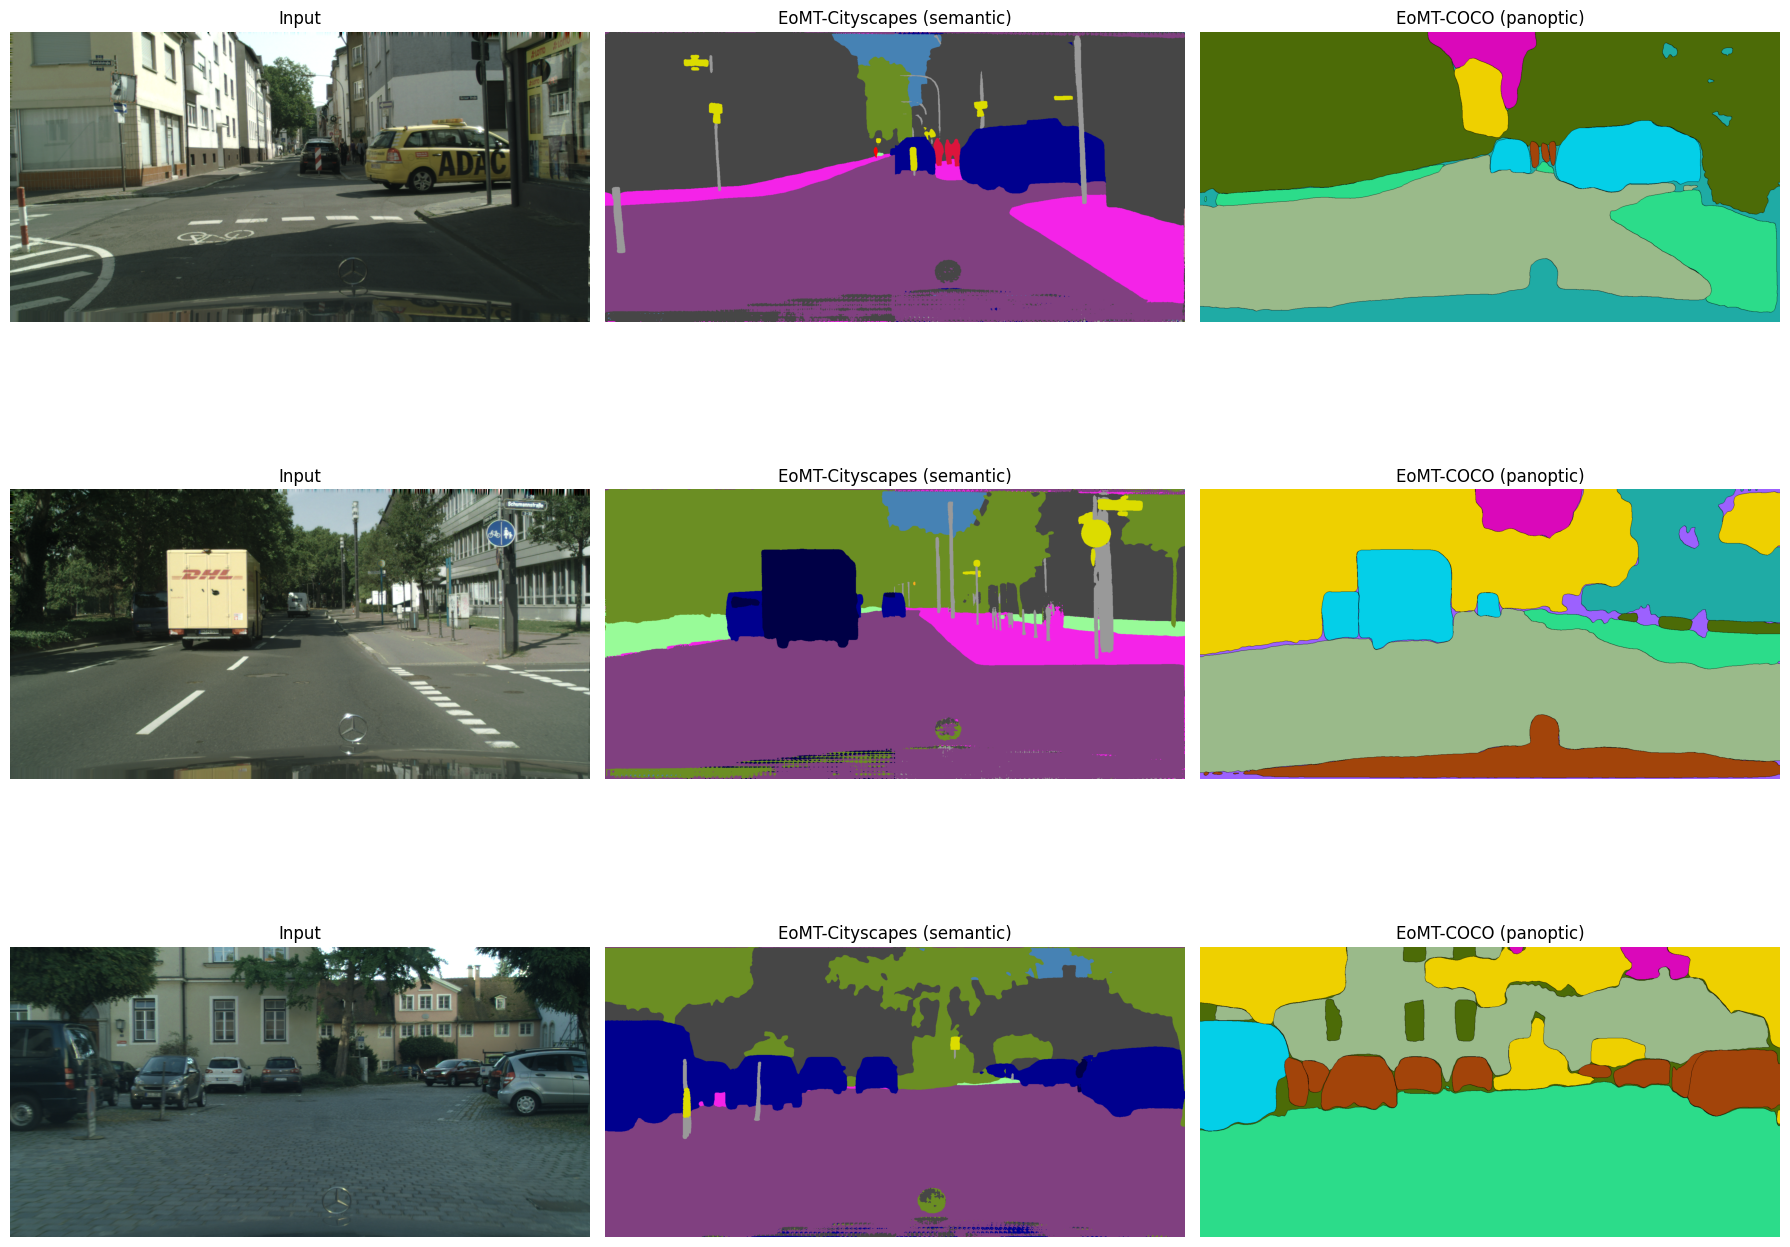

saved /content/step4_compare.png


In [ ]:
import gc, numpy as np, torch, torch.nn.functional as F, matplotlib.pyplot as plt
from torch.amp.autocast_mode import autocast
IDX=[0,150,300]; imgs=[ds[i][0] for i in IDX]
CS_COLORS=np.array([(128,64,128),(244,35,232),(70,70,70),(102,102,156),(190,153,153),
 (153,153,153),(250,170,30),(220,220,0),(107,142,35),(152,251,152),(70,130,180),
 (220,20,60),(255,0,0),(0,0,142),(0,0,70),(0,60,100),(0,80,100),(0,0,230),(119,11,32)],dtype=np.uint8)
try: del model
except: pass
torch.cuda.empty_cache(); gc.collect()
csm=M.build_model("configs/dinov2/cityscapes/semantic/eomt_base_640.yaml",
                  "../eomt_ckpt/eomt_cityscapes.bin","cuda",num_classes=19,img_size=(1024,1024))
@torch.no_grad()
def sem_pred(model,img):
    crops,origins=model.window_imgs_semantic([img.to("cuda")])
    with autocast(dtype=torch.float16,device_type="cuda"):
        ml,cl=model(crops); ml=F.interpolate(ml[-1],model.img_size,mode="bilinear")
        cl_=model.to_per_pixel_logits_semantic(ml,cl[-1])
    return model.revert_window_logits_semantic(cl_,origins,[img.shape[-2:]])[0].argmax(0).cpu().numpy()
sem=[sem_pred(csm,im) for im in imgs]; del csm; torch.cuda.empty_cache(); gc.collect()
cm=M.build_model("configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml",
                 "../eomt_ckpt/eomt_coco.bin","cuda",num_classes=133,img_size=(640,640))
@torch.no_grad()
def pan_pred(model,img):
    sizes=[img.shape[-2:]]
    t=model.resize_and_pad_imgs_instance_panoptic([img.to("cuda")])
    with autocast(dtype=torch.float16,device_type="cuda"):
        ml,cl=model(t); ml=F.interpolate(ml[-1],model.img_size,mode="bilinear")
        ml=model.revert_resize_and_pad_logits_instance_panoptic(ml,sizes)
    p=model.to_per_pixel_preds_panoptic(ml,cl[-1],model.stuff_classes,model.mask_thresh,model.overlap_thresh)[0].cpu().numpy()
    return p[...,0],p[...,1]
pan=[pan_pred(cm,im) for im in imgs]; del cm; torch.cuda.empty_cache(); gc.collect()
def color_sem(s):
    out=np.zeros((*s.shape,3),np.uint8)
    for c in range(19): out[s==c]=CS_COLORS[c]
    return out
def color_pan(si,ii):
    ids=np.unique(si); rng=np.random.default_rng(0)
    cmap={c:(rng.random(3)*255).astype(np.uint8) for c in ids}
    out=np.zeros((*si.shape,3),np.uint8)
    for c in ids: out[si==c]=cmap[c]
    comb=si.astype(np.int64)*100000+ii.astype(np.int64); b=np.zeros(si.shape,bool)
    b[1:,:]|=comb[1:,:]!=comb[:-1,:]; b[:,1:]|=comb[:,1:]!=comb[:,:-1]; out[b]=0
    return out
fig,ax=plt.subplots(len(IDX),3,figsize=(18,5*len(IDX)))
for r,im in enumerate(imgs):
    ax[r,0].imshow(im.permute(1,2,0).numpy()); ax[r,0].set_title("Input")
    ax[r,1].imshow(color_sem(sem[r]));         ax[r,1].set_title("EoMT-Cityscapes (semantic)")
    ax[r,2].imshow(color_pan(*pan[r]));        ax[r,2].set_title("EoMT-COCO (panoptic)")
    for c in range(3): ax[r,c].axis("off")
plt.tight_layout(); plt.savefig("/content/step4_compare.png",dpi=120,bbox_inches="tight"); plt.show()
print("saved /content/step4_compare.png")

## 7. (Step 5) Fine-tune the COCO model on Cityscapes (head-only)
Build a SEMANTIC EoMT (19 classes) keeping COCO's 200 queries; load `eomt_coco.bin` with
`load_ckpt_class_head=False` (transfers backbone+queries+mask-head, reinitialises the head).
Freeze everything except the new class head, train with AMP. ~9 min for 600 steps.

In [ ]:
%cd /content/MaskArchitectureAnomaly_CourseProject/eomt
import yaml, importlib, torch, gc, numpy as np
from lightning.pytorch import Trainer
gc.collect(); torch.cuda.empty_cache()
cfg=yaml.safe_load(open("configs/dinov2/cityscapes/semantic/eomt_base_640.yaml"))
enc=cfg["model"]["init_args"]["network"]["init_args"]["encoder"]; m,c=enc["class_path"].rsplit(".",1)
encoder=getattr(importlib.import_module(m),c)(img_size=(640,640), **enc.get("init_args",{}))
m,c=cfg["model"]["init_args"]["network"]["class_path"].rsplit(".",1)
network=getattr(importlib.import_module(m),c)(num_q=200,num_blocks=3,masked_attn_enabled=True,num_classes=19,encoder=encoder)
m,c=cfg["model"]["class_path"].rsplit(".",1)
ft=getattr(importlib.import_module(m),c)(img_size=(640,640),num_classes=19,network=network,
     attn_mask_annealing_enabled=False, ckpt_path="../eomt_ckpt/eomt_coco.bin", load_ckpt_class_head=False)
for nm,p in ft.named_parameters(): p.requires_grad=("class_head" in nm)
print("trainable tensors:", sum(p.requires_grad for p in ft.parameters()))
dm,dc=cfg["data"]["class_path"].rsplit(".",1)
data=getattr(importlib.import_module(dm),dc)(path="/content/cityscapes",batch_size=2,num_workers=2,
        img_size=(640,640),check_empty_targets=True)
Trainer(max_steps=600,precision="16-mixed",accelerator="gpu",devices=1,enable_checkpointing=False,
        logger=False,num_sanity_val_steps=0,limit_val_batches=0).fit(ft,datamodule=data)
torch.save(ft.state_dict(),"/content/assets/eomt_finetuned.bin"); print("saved eomt_finetuned.bin")

/content/MaskArchitectureAnomaly_CourseProject/eomt


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'network' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['network'])`.
INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, tr

trainable tensors: 2


INFO: You are using a CUDA device ('NVIDIA A100-SXM4-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
INFO:lightning.pytorch.utilities.rank_zero:You are using a CUDA device ('NVIDIA A100-SXM4-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/model_summary/model_summary.

┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ network   │ EoMT                   │ 93.6 M │ train │     0 │
│ 1 │ criterion │ MaskClassificationLoss │      0 │ train │     0 │
│ 2 │ metrics   │ ModuleList             │      0 │ train │     0 │
└───┴───────────┴────────────────────────┴────────┴───────┴───────┘

...

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/core/module.py:1333: Detected call of 
`lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite 
order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the 
first value of the learning rate schedule. See more details at 
https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate

INFO: `Trainer.fit` stopped: `max_steps=600` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=600` reached.


saved eomt_finetuned.bin


### Evaluate the extended head-only model

Reuses `eval_miou`, `run_eomt`, `CS_NAMES`, `SHARED` from earlier cells.

- **`ft_head.cuda().eval()`** — Lightning's `Trainer.fit` leaves the model on CPU; moving it
  to GPU + eval mode is required before inference (without this you get a
  CPU↔CUDA device-mismatch error in `eval_miou`).
- **`eval_miou(..., None, TAG)`** — runs windowed semantic inference over the full
  Cityscapes val set, returns per-class IoU; `remap=None` because the head-only model already
  predicts Cityscapes classes directly (no COCO→Cityscapes mapping needed).
- **mIoU(19)** = mean over all 19 classes; **mIoU(17 shared)** = mean excluding `pole` and
  `rider` (the two classes COCO cannot represent), for a fair head-to-head with the
  COCO/Cityscapes baselines.
- **`run_eomt(ft_head)`** — runs the 4 post-hoc anomaly scores
  (MSP / MaxLogit / MaxEntropy / RbA) on all 5 validation datasets and prints the
  AuPRC / FPR95 table.



### Step 5 — fine-tuned mIoU vs COCO vs Cityscapes (reuses `ds`,`eval_miou`,`SHARED` from cell 6)

In [ ]:
import numpy as np
ft = ft.cuda().eval()
iou_ft = eval_miou(ft, None, "FT")
print("Fine-tuned per-class IoU:")
for n,v in zip(CS_NAMES, iou_ft): print(f"  {n:14s}{v*100:5.1f}")
print(f"\nmIoU(19)={np.mean(iou_ft)*100:.2f}  mIoU(17 shared)={np.mean(iou_ft[SHARED])*100:.2f}")

  FT 100/500
  FT 200/500
  FT 300/500
  FT 400/500
  FT 500/500
Fine-tuned per-class IoU:
  road           95.6
  sidewalk       70.1
  building       76.4
  wall            0.3
  fence           1.7
  pole            5.6
  traffic light  51.1
  traffic sign   20.4
  vegetation     81.5
  terrain        48.5
  sky            90.5
  person         66.4
  rider           0.0
  car            85.3
  truck           0.0
  bus             2.5
  train           0.0
  motorcycle      0.0
  bicycle        64.5

mIoU(19)=40.01  mIoU(17 shared)=44.39


[link text](https://)### Step 8 (fine-tuned checkpoint) — anomaly row (reuses `run_eomt` from cell 4)

In [ ]:
print("=== EoMT-finetuned anomaly baselines ===")
res_ft=run_eomt(ft)

=== EoMT-finetuned anomaly baselines ===
RA-21       msp         AuPRC= 39.38 FPR95= 82.25
RA-21       maxlogit    AuPRC= 40.38 FPR95= 84.05
RA-21       maxentropy  AuPRC= 43.61 FPR95= 81.26
RA-21       rba         AuPRC= 18.09 FPR95= 98.40
RO-21       msp         AuPRC= 86.01 FPR95= 49.14
RO-21       maxlogit    AuPRC= 81.50 FPR95= 94.93
RO-21       maxentropy  AuPRC= 83.66 FPR95= 89.93
RO-21       rba         AuPRC= 57.19 FPR95=100.00
FS L&F      msp         AuPRC=  1.86 FPR95= 87.00
FS L&F      maxlogit    AuPRC=  1.13 FPR95= 89.88
FS L&F      maxentropy  AuPRC=  1.17 FPR95= 87.24
FS L&F      rba         AuPRC=  0.28 FPR95= 98.94
FS Static   msp         AuPRC= 42.58 FPR95= 16.55
FS Static   maxlogit    AuPRC= 37.19 FPR95= 22.41
FS Static   maxentropy  AuPRC= 35.79 FPR95= 15.80
FS Static   rba         AuPRC=  4.02 FPR95= 89.22
RoadAnomaly msp         AuPRC= 52.82 FPR95= 77.19
RoadAnomaly maxlogit    AuPRC= 50.00 FPR95= 83.20
RoadAnomaly maxentropy  AuPRC= 52.90 FPR95= 78.56
RoadAnoma

### Extended head-only fine-tune (more epochs of v1)

Same unfreezing as **v1** (only the new 19-class head, ~15 K trainable params), trained
for **more epochs** to test the head-only ceiling.

- **Unfrozen:** `class_head` only.
- **Frozen:** everything else — backbone, mask head, queries, upscale, patch embedding.
- **Budget:** `MAX_STEPS` (default 7500), `batch_size=2`, no gradient accumulation
  → ≈5 epochs of Cityscapes train.
- **AMP** (`precision="16-mixed"`), 200 queries retained from COCO (frozen).
- Checkpoint saved to `{ASSETS}/eomt_finetuned_v1_head_long_<MAX_STEPS>.bin`.

*"unlimited head-only training cannot break the recipe's capacity limit."*

In [ ]:
%cd /content/MaskArchitectureAnomaly_CourseProject/eomt
import yaml, importlib, torch, gc
from lightning.pytorch import Trainer
gc.collect(); torch.cuda.empty_cache()

MAX_STEPS = 7500          # ← change this. 7500 ≈ 5 epochs (head-only, no grad accum)
TAG       = f"v1_head_long_{MAX_STEPS}"

# --- build SEMANTIC EoMT (19 classes, 200 queries from COCO), load COCO weights, reinit head ---
cfg = yaml.safe_load(open("configs/dinov2/cityscapes/semantic/eomt_base_640.yaml"))
enc = cfg["model"]["init_args"]["network"]["init_args"]["encoder"]
m,c = enc["class_path"].rsplit(".",1)
encoder = getattr(importlib.import_module(m),c)(img_size=(640,640), **enc.get("init_args",{}))
m,c = cfg["model"]["init_args"]["network"]["class_path"].rsplit(".",1)
network = getattr(importlib.import_module(m),c)(
    num_q=200, num_blocks=3, masked_attn_enabled=True, num_classes=19, encoder=encoder)
m,c = cfg["model"]["class_path"].rsplit(".",1)
ft_head = getattr(importlib.import_module(m),c)(
    img_size=(640,640), num_classes=19, network=network,
    attn_mask_annealing_enabled=False,
    ckpt_path="../eomt_ckpt/eomt_coco.bin", load_ckpt_class_head=False)

# --- HEAD-ONLY: only the new 19-class head is trainable ---
for nm,p in ft_head.named_parameters():
    p.requires_grad = ("class_head" in nm)
print("trainable tensors:", sum(p.requires_grad for p in ft_head.parameters()),
      "| params:", sum(p.numel() for p in ft_head.parameters() if p.requires_grad)/1e3, "K")

# --- Cityscapes train data ---
dm,dc = cfg["data"]["class_path"].rsplit(".",1)
data = getattr(importlib.import_module(dm),dc)(
    path="/content/cityscapes", batch_size=2, num_workers=2, img_size=(640,640), check_empty_targets=True)

# --- train ---
Trainer(
    max_steps=MAX_STEPS, precision="16-mixed",
    accelerator="gpu", devices=1,
    enable_checkpointing=False, logger=False,
    num_sanity_val_steps=0, limit_val_batches=0,
).fit(ft_head, datamodule=data)

# --- save ---
ckpt_path = f"/content/assets/eomt_finetuned_{TAG}.bin"
torch.save(ft_head.state_dict(), ckpt_path)
print(f"saved {ckpt_path}")

/content/MaskArchitectureAnomaly_CourseProject/eomt


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'network' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['network'])`.
INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, tr

trainable tensors: 2 | params: 15.38 K


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ network   │ EoMT                   │ 93.6 M │ train │     0 │
│ 1 │ criterion │ MaskClassificationLoss │      0 │ train │     0 │
│ 2 │ metrics   │ ModuleList             │      0 │ train │     0 │
└───┴───────────┴────────────────────────┴────────┴───────┴───────┘

...

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/core/module.py:1333: Detected call of 
`lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite 
order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the 
first value of the learning rate schedule. See more details at 
https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate

INFO: `Trainer.fit` stopped: `max_steps=7500` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=7500` reached.


saved /content/assets/eomt_finetuned_v1_head_long_7500.bin


### Evaluate the extended head-only model

Reuses `eval_miou`, `run_eomt`, `CS_NAMES`, `SHARED` from earlier cells.

- **`ft_head.cuda().eval()`** — Lightning's `Trainer.fit` leaves the model on CPU; moving it
  to GPU + eval mode is required before inference (without this you get a
  CPU↔CUDA device-mismatch error in `eval_miou`).
- **`eval_miou(..., None, TAG)`** — runs windowed semantic inference over the full
  Cityscapes val set, returns per-class IoU; `remap=None` because the head-only model already
  predicts Cityscapes classes directly (no COCO→Cityscapes mapping needed).
- **mIoU(19)** = mean over all 19 classes; **mIoU(17 shared)** = mean excluding `pole` and
  `rider` (the two classes COCO cannot represent), for a fair head-to-head with the
  COCO/Cityscapes baselines.
- **`run_eomt(ft_head)`** — runs the 4 post-hoc anomaly scores
  (MSP / MaxLogit / MaxEntropy / RbA) on all 5 validation datasets and prints the
  AuPRC / FPR95 table.


In [ ]:
import numpy as np
ft_head = ft_head.cuda().eval()
iou = eval_miou(ft_head, None, TAG)
for n,v in zip(CS_NAMES, iou): print(f"  {n:14s}{v*100:5.1f}")
print(f"\nmIoU(19)={np.mean(iou)*100:.2f}  mIoU(17 shared)={np.mean(iou[SHARED])*100:.2f}")
print(f"=== {TAG} anomaly ===")
run_eomt(ft_head)

  v1_head_long_7500 100/500
  v1_head_long_7500 200/500
  v1_head_long_7500 300/500
  v1_head_long_7500 400/500
  v1_head_long_7500 500/500
  road           96.1
  sidewalk       72.5
  building       77.9
  wall           56.3
  fence          45.7
  pole            9.3
  traffic light  56.3
  traffic sign   31.1
  vegetation     85.7
  terrain        55.4
  sky            90.1
  person         63.5
  rider          11.5
  car            89.1
  truck          57.0
  bus            81.1
  train          66.4
  motorcycle     60.5
  bicycle        68.6

mIoU(19)=61.80  mIoU(17 shared)=67.84
=== v1_head_long_7500 anomaly ===
RA-21       msp         AuPRC= 34.41 FPR95= 99.87
RA-21       maxlogit    AuPRC= 32.81 FPR95= 99.83
RA-21       maxentropy  AuPRC= 31.09 FPR95= 99.86
RA-21       rba         AuPRC= 20.57 FPR95= 96.53
RO-21       msp         AuPRC= 90.86 FPR95=  1.56
RO-21       maxlogit    AuPRC= 90.75 FPR95=  2.24
RO-21       maxentropy  AuPRC= 90.09 FPR95=  2.65
RO-21       rba    

{('RA-21', 'msp'): (np.float64(34.40734735520628), 99.86649185397766),
 ('RA-21', 'maxlogit'): (np.float64(32.81308954091264), 99.83477804854705),
 ('RA-21', 'maxentropy'): (np.float64(31.08950205529058), 99.85913994137418),
 ('RA-21', 'rba'): (np.float64(20.573795386299853), 96.53425771239125),
 ('RO-21', 'msp'): (np.float64(90.86246766940164), 1.5590314249950854),
 ('RO-21', 'maxlogit'): (np.float64(90.74544515113924), 2.238433941012056),
 ('RO-21', 'maxentropy'): (np.float64(90.09380212086823), 2.650152054114973),
 ('RO-21', 'rba'): (np.float64(80.82417237694895), 93.34773589397304),
 ('FS L&F', 'msp'): (np.float64(2.047049057292951), 93.76170249117136),
 ('FS L&F', 'maxlogit'): (np.float64(1.8761158586556397), 94.4529620833771),
 ('FS L&F', 'maxentropy'): (np.float64(1.678220169423107), 94.27758325803894),
 ('FS L&F', 'rba'): (np.float64(0.31024638844073515), 98.69722654394525),
 ('FS Static', 'msp'): (np.float64(33.15661850781298), 14.601970712903878),
 ('FS Static', 'maxlogit'): 

## Step 5 (v2): Deeper fine-tuning of the COCO model on Cityscapes

The head-only fine-tune (only the 19-class head, frozen rest, ~0.4 epoch) adapted the
dominant classes (road 0→95.6) but left rare classes uncovered (truck/bus/train/
motorcycle ≈ 0), giving mIoU(17-shared) = 44.3 — below the COCO baseline (55.5).

**v2 increases capacity and training budget** following  "gradually unfreeze"
guidance:
- **Unfrozen:** class head + **mask head** + **learnable queries** (`q`) + upscale block.
  This lets the model reshape COCO's object masks into Cityscapes objects, not just
  relabel them.
- **Frozen:** the DINOv2 backbone (keeps it Colab-friendly; caps the ceiling below the
  fully-trained Cityscapes model).
- **Budget:** `max_steps=3000`, `batch_size=2` ≈ **2 epochs** of Cityscapes train (2975 imgs).
- AMP (`16-mixed`), 200 queries retained from COCO, evaluated with the same `eval_miou`
  pipeline for a fair comparison.

rare classes recover, so mIoU(17-shared) should rise past the COCO baseline
(55.5) toward — but below — the fully-trained Cityscapes model (82.9). Saved to
`eomt_finetuned_v2.bin`.

In [ ]:
%cd /content/MaskArchitectureAnomaly_CourseProject/eomt
import yaml, importlib, torch, gc
from lightning.pytorch import Trainer

gc.collect()
torch.cuda.empty_cache()

cfg = yaml.safe_load(open("configs/dinov2/cityscapes/semantic/eomt_base_640.yaml"))

# encoder (DINOv2 base ViT)
enc = cfg["model"]["init_args"]["network"]["init_args"]["encoder"]
m, c = enc["class_path"].rsplit(".", 1)
encoder = getattr(importlib.import_module(m), c)(
    img_size=(640, 640),
    **enc.get("init_args", {})
)

# EoMT network (keep 200 queries from COCO; predict 19 Cityscapes classes)
m, c = cfg["model"]["init_args"]["network"]["class_path"].rsplit(".", 1)
network = getattr(importlib.import_module(m), c)(
    num_q=200,
    num_blocks=3,
    masked_attn_enabled=True,
    num_classes=19,
    encoder=encoder
)

# Lightning module: load COCO weights, reinitialise the 19-class head
m, c = cfg["model"]["class_path"].rsplit(".", 1)
ft2 = getattr(importlib.import_module(m), c)(
    img_size=(640, 640),
    num_classes=19,
    network=network,
    attn_mask_annealing_enabled=False,
    ckpt_path="../eomt_ckpt/eomt_coco.bin",
    load_ckpt_class_head=False
)

# UNFREEZE: class head + mask head + queries + upscale.  Backbone stays frozen.
TRAIN = ("class_head", "mask_head", "upscale", ".q.")
for nm, p in ft2.named_parameters():
    p.requires_grad = any(k in nm for k in TRAIN)
print("trainable tensors:", sum(p.requires_grad for p in ft2.parameters()))

# Cityscapes train split (reads the zips directly)
dm, dc = cfg["data"]["class_path"].rsplit(".", 1)
data = getattr(importlib.import_module(dm), dc)(
    path="/content/cityscapes",
    batch_size=2,
    num_workers=2,
    img_size=(640, 640),
    check_empty_targets=True
)

# Train ~2 epochs (2975 train images ÷ batch 2 ≈ 1487 steps/epoch → 3000 ≈ 2.0 epochs)
Trainer(
    max_steps=3000,
    precision="16-mixed",
    accelerator="gpu",
    devices=1,
    enable_checkpointing=False,
    logger=False,
    num_sanity_val_steps=0,
    limit_val_batches=0
).fit(ft2, datamodule=data)

torch.save(ft2.state_dict(), "/content/assets/eomt_finetuned_v2.bin")
print("saved eomt_finetuned_v2.bin")

/content/MaskArchitectureAnomaly_CourseProject/eomt


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'network' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['network'])`.
INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, tr

trainable tensors: 19


...

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/core/module.py:1333: Detected call of 
`lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite 
order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the 
first value of the learning rate schedule. See more details at 
https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate

INFO: `Trainer.fit` stopped: `max_steps=3000` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=3000` reached.


saved eomt_finetuned_v2.bin


5Epocs

In [ ]:
%cd /content/MaskArchitectureAnomaly_CourseProject/eomt
import yaml, importlib, torch, gc
from lightning.pytorch import Trainer
gc.collect(); torch.cuda.empty_cache()
cfg=yaml.safe_load(open("configs/dinov2/cityscapes/semantic/eomt_base_640.yaml"))
enc=cfg["model"]["init_args"]["network"]["init_args"]["encoder"]; m,c=enc["class_path"].rsplit(".",1)
encoder=getattr(importlib.import_module(m),c)(img_size=(640,640), **enc.get("init_args",{}))
m,c=cfg["model"]["init_args"]["network"]["class_path"].rsplit(".",1)
network=getattr(importlib.import_module(m),c)(num_q=200,num_blocks=3,masked_attn_enabled=True,num_classes=19,encoder=encoder)
m,c=cfg["model"]["class_path"].rsplit(".",1)
ft3=getattr(importlib.import_module(m),c)(img_size=(640,640),num_classes=19,network=network,
     attn_mask_annealing_enabled=False, ckpt_path="../eomt_ckpt/eomt_coco.bin", load_ckpt_class_head=False)
TRAIN=("class_head","mask_head","upscale",".q.")
for nm,p in ft3.named_parameters(): p.requires_grad=any(k in nm for k in TRAIN)
print("trainable tensors:", sum(p.requires_grad for p in ft3.parameters()))
dm,dc=cfg["data"]["class_path"].rsplit(".",1)
data=getattr(importlib.import_module(dm),dc)(path="/content/cityscapes",batch_size=2,num_workers=2,
        img_size=(640,640),check_empty_targets=True)
Trainer(max_steps=7500,precision="16-mixed",accelerator="gpu",devices=1,enable_checkpointing=False,
        logger=False,num_sanity_val_steps=0,limit_val_batches=0).fit(ft3,datamodule=data)   # ~5 epochs
torch.save(ft3.state_dict(),"/content/assets/eomt_finetuned_v3.bin"); print("saved v3 (5 epochs)")

/content/MaskArchitectureAnomaly_CourseProject/eomt


INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


trainable tensors: 19


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ network   │ EoMT                   │ 93.6 M │ train │     0 │
│ 1 │ criterion │ MaskClassificationLoss │      0 │ train │     0 │
│ 2 │ metrics   │ ModuleList             │      0 │ train │     0 │
└───┴───────────┴────────────────────────┴────────┴───────┴───────┘

Trainable params: 6.7 M                                                                                            
Non-trainable params: 86.9 M                                                                                       
Total params: 93.6 M                                                                                               
Total estimated model params size (MB): 374.302                                                                    
Modules in train mode: 304                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO: `Trainer.fit` stopped: `max_steps=7500` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=7500` reached.


saved v3 (5 epochs)


In [ ]:
import numpy as np, torch
ft3 = ft3.cuda().eval()           # Trainer.fit leaves it on CPU
iou_v3 = eval_miou(ft3, None, "V3")
print("v3 (5 epochs) per-class IoU:")
for n, v in zip(CS_NAMES, iou_v3): print(f"  {n:14s}{v*100:5.1f}")
print(f"\nmIoU(19)={np.mean(iou_v3)*100:.2f}  mIoU(17 shared)={np.mean(iou_v3[SHARED])*100:.2f}")
print("\n--- Step 5 progression (17 shared) ---")
print(f"  COCO            55.46")
print(f"  v1 head-only    44.28")
print(f"  v2 (2 epochs)   70.02")
print(f"  v3 (5 epochs)   {np.mean(iou_v3[SHARED])*100:.2f}")
print(f"  Cityscapes ref  82.93")

  V3 100/500
  V3 200/500
  V3 300/500
  V3 400/500
  V3 500/500
v3 (5 epochs) per-class IoU:
  road           97.5
  sidewalk       81.0
  building       91.6
  wall           60.3
  fence          54.2
  pole           51.9
  traffic light  64.5
  traffic sign   70.1
  vegetation     91.3
  terrain        66.9
  sky            94.1
  person         74.0
  rider          22.0
  car            93.1
  truck          69.5
  bus            83.3
  train          65.1
  motorcycle     57.5
  bicycle        73.7

mIoU(19)=71.66  mIoU(17 shared)=75.75

--- Step 5 progression (17 shared) ---
  COCO            55.46
  v1 head-only    44.28
  v2 (2 epochs)   70.02
  v3 (5 epochs)   75.75
  Cityscapes ref  82.93


(fine-tuned checkpoint) — anomaly row (reuses run_eomt from cell 4)*italicized text*

In [ ]:
print("=== v3 anomaly ==="); res_v3 = run_eomt(ft3)

=== v3 anomaly ===
RA-21       msp         AuPRC= 74.81 FPR95= 10.33
RA-21       maxlogit    AuPRC= 72.86 FPR95= 10.48
RA-21       maxentropy  AuPRC= 73.52 FPR95=  9.95
RA-21       rba         AuPRC= 52.58 FPR95= 99.16
RO-21       msp         AuPRC= 80.41 FPR95=  0.82
RO-21       maxlogit    AuPRC= 78.94 FPR95=  0.87
RO-21       maxentropy  AuPRC= 78.72 FPR95=  0.77
RO-21       rba         AuPRC= 63.72 FPR95= 96.54
FS L&F      msp         AuPRC= 41.66 FPR95= 15.39
FS L&F      maxlogit    AuPRC= 39.99 FPR95= 15.97
FS L&F      maxentropy  AuPRC= 42.07 FPR95= 18.54
FS L&F      rba         AuPRC= 32.35 FPR95= 89.58
FS Static   msp         AuPRC= 82.31 FPR95= 16.06
FS Static   maxlogit    AuPRC= 80.80 FPR95= 17.13
FS Static   maxentropy  AuPRC= 76.30 FPR95= 15.21
FS Static   rba         AuPRC= 73.31 FPR95= 88.03
RoadAnomaly msp         AuPRC= 68.07 FPR95= 23.76
RoadAnomaly maxlogit    AuPRC= 66.40 FPR95= 23.00
RoadAnomaly maxentropy  AuPRC= 55.52 FPR95= 21.86
RoadAnomaly rba         AuPRC= 

### v4 — Deep fine-tune: v3 set + last 4 DINOv2 blocks unfrozen

The deepest variant. Adds backbone adaptation on top of v3's recipe, so the model can
adapt the **features themselves** (not just the prediction stack).

- **Unfrozen:** `class_head` + `mask_head` + queries (`q`) + `upscale` + DINOv2 blocks
  `{8, 9, 10, 11}` (the last 4 of 12) → **~35 M trainable parameters**.
- **Frozen:** the first 8 DINOv2 blocks, patch embedding, register tokens.
- **Budget:** `max_steps = 7500`, `batch_size = 2`, `accumulate_grad_batches = 4`
  → effective batch 8 (reduces Hungarian-matching noise), ≈ **20 epochs** of Cityscapes
  train (2975 images).
- **AMP** (`precision="16-mixed"`); 200 queries retained from COCO.
- Checkpoint saved to `{ASSETS}/eomt_finetuned_v4.bin`.



In [ ]:
%cd /content/MaskArchitectureAnomaly_CourseProject/eomt
import yaml, importlib, torch, gc
from lightning.pytorch import Trainer
gc.collect(); torch.cuda.empty_cache()

cfg = yaml.safe_load(open("configs/dinov2/cityscapes/semantic/eomt_base_640.yaml"))
enc = cfg["model"]["init_args"]["network"]["init_args"]["encoder"]; m,c = enc["class_path"].rsplit(".",1)
encoder = getattr(importlib.import_module(m),c)(img_size=(640,640), **enc.get("init_args",{}))
m,c = cfg["model"]["init_args"]["network"]["class_path"].rsplit(".",1)
network = getattr(importlib.import_module(m),c)(num_q=200,num_blocks=3,masked_attn_enabled=True,num_classes=19,encoder=encoder)
m,c = cfg["model"]["class_path"].rsplit(".",1)
ft4 = getattr(importlib.import_module(m),c)(img_size=(640,640),num_classes=19,network=network,
      attn_mask_annealing_enabled=False, ckpt_path="../eomt_ckpt/eomt_coco.bin", load_ckpt_class_head=False)

# unfreeze: head + mask head + queries + upscale + last 4 DINOv2 blocks
TOP=("class_head","mask_head","upscale",".q."); UNFROZEN_BLOCKS={8,9,10,11}
for nm,p in ft4.named_parameters():
    in_top   = any(k in nm for k in TOP)
    in_block = "blocks." in nm and int(nm.split("blocks.")[1].split(".")[0]) in UNFROZEN_BLOCKS
    p.requires_grad = in_top or in_block
print("trainable params:", sum(p.numel() for p in ft4.parameters() if p.requires_grad)/1e6, "M")

dm,dc = cfg["data"]["class_path"].rsplit(".",1)
data = getattr(importlib.import_module(dm),dc)(path="/content/cityscapes",batch_size=2,num_workers=2,
       img_size=(640,640),check_empty_targets=True)
Trainer(max_steps=7500, precision="16-mixed", accelerator="gpu", devices=1,
        accumulate_grad_batches=4, enable_checkpointing=False, logger=False,
        num_sanity_val_steps=0, limit_val_batches=0).fit(ft4, datamodule=data)   # ~20 epochs
torch.save(ft4.state_dict(),"/content/assets/eomt_finetuned_v4.bin"); print("saved v4")

/content/MaskArchitectureAnomaly_CourseProject/eomt


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'network' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['network'])`.
INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, tr

trainable params: 35.035412 M


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ network   │ EoMT                   │ 93.6 M │ train │     0 │
│ 1 │ criterion │ MaskClassificationLoss │      0 │ train │     0 │
│ 2 │ metrics   │ ModuleList             │      0 │ train │     0 │
└───┴───────────┴────────────────────────┴────────┴───────┴───────┘

...

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/core/module.py:1333: Detected call of 
`lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite 
order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the 
first value of the learning rate schedule. See more details at 
https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate

INFO: `Trainer.fit` stopped: `max_steps=7500` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=7500` reached.


saved v4


In [ ]:
import numpy as np, torch
ft4 = ft4.cuda().eval()
torch.save(ft4.state_dict(), "/content/assets/eomt_finetuned_v4.bin")
iou_v4 = eval_miou(ft4, None, "V4")
print("Option A (last-4-blocks, ~20ep) per-class IoU:")
for n,v in zip(CS_NAMES, iou_v4): print(f"  {n:14s}{v*100:5.1f}")
print(f"\nmIoU(19)={np.mean(iou_v4)*100:.2f}  mIoU(17 shared)={np.mean(iou_v4[SHARED])*100:.2f}")
print("\n--- Step 5 final progression (17 shared) ---")
print("  COCO 55.46 | v1 44.28 | v2 70.02 | v3 75.84 | Option A {:.2f} | Cityscapes 82.93".format(np.mean(iou_v4[SHARED])*100))
print("\n=== Option A anomaly ==="); run_eomt(ft4)

  V4 100/500
  V4 200/500
  V4 300/500
  V4 400/500
  V4 500/500
Option A (last-4-blocks, ~20ep) per-class IoU:
  road           98.0
  sidewalk       84.0
  building       92.7
  wall           61.0
  fence          60.3
  pole           59.7
  traffic light  66.8
  traffic sign   76.2
  vegetation     91.9
  terrain        65.3
  sky            94.5
  person         81.7
  rider          62.3
  car            94.8
  truck          81.6
  bus            79.3
  train          41.9
  motorcycle     60.8
  bicycle        76.4

mIoU(19)=75.21  mIoU(17 shared)=76.88

--- Step 5 final progression (17 shared) ---
  COCO 55.46 | v1 44.28 | v2 70.02 | v3 75.84 | Option A 76.88 | Cityscapes 82.93

=== Option A anomaly ===
RA-21       msp         AuPRC= 76.24 FPR95= 42.77
RA-21       maxlogit    AuPRC= 71.21 FPR95= 81.66
RA-21       maxentropy  AuPRC= 68.73 FPR95= 90.83
RA-21       rba         AuPRC= 57.24 FPR95= 99.88
RO-21       msp         AuPRC= 93.36 FPR95=  0.26
RO-21       maxlogit    AuP

{('RA-21', 'msp'): (np.float64(76.2365680852718), 42.77070729632191),
 ('RA-21', 'maxlogit'): (np.float64(71.20930079275664), 81.65816444745262),
 ('RA-21', 'maxentropy'): (np.float64(68.72521319320506), 90.8327770516531),
 ('RA-21', 'rba'): (np.float64(57.23885792364594), 99.88285577021439),
 ('RO-21', 'msp'): (np.float64(93.36001459997284), 0.26391757370172186),
 ('RO-21', 'maxlogit'): (np.float64(93.29105979244883), 0.27074734375347),
 ('RO-21', 'maxentropy'): (np.float64(92.3438134854631), 0.2786734709436861),
 ('RO-21', 'rba'): (np.float64(89.73714228973093), 0.47977334137787964),
 ('FS L&F', 'msp'): (np.float64(44.51116171547762), 18.772512506658785),
 ('FS L&F', 'maxlogit'): (np.float64(43.2429096193762), 18.686618227362878),
 ('FS L&F', 'maxentropy'): (np.float64(37.35255906489225), 18.30275771617396),
 ('FS L&F', 'rba'): (np.float64(42.23936040558387), 82.05191214574091),
 ('FS Static', 'msp'): (np.float64(80.88539879916439), 15.281910714139865),
 ('FS Static', 'maxlogit'): (n

In [ ]:
!pip uninstall -y torchao

In [ ]:
import torch
import peft

print("torch:", torch.__version__)
print("peft:", peft.__version__)

torch: 2.11.0+cu128
peft: 0.19.1


In [ ]:
!pip install -U torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 105.2 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [ ]:
# Check that frozen backbone really has no gradients except LoRA
for name, p in ft.named_parameters():
    if p.requires_grad:
        print(name)

In [ ]:
# ============================================================
# Apply LoRA to ft3 backbone after torchao fix
# Run this AFTER you build/load ft3
# ============================================================

import torch
import warnings
warnings.filterwarnings("ignore")

from peft import LoraConfig, get_peft_model


# ------------------------------------------------------------
# 2. Get backbone
# ------------------------------------------------------------
backbone = ft.network.encoder.backbone

print("\nBackbone type:")
print(type(backbone))

# ------------------------------------------------------------
# 3. Inspect possible LoRA target modules
# ------------------------------------------------------------
print("\nPossible attention/projection module names:")
candidate_names = []

for name, module in backbone.named_modules():
    lname = name.lower()
    if any(key in lname for key in ["qkv", "query", "key", "value", "proj", "attn"]):
        candidate_names.append(name)
        print(name)

if len(candidate_names) == 0:
    print("No obvious attention modules found. You may need different target_modules.")

# ------------------------------------------------------------
# 4. Freeze original backbone
# ------------------------------------------------------------
for p in backbone.parameters():
    p.requires_grad = False

# ------------------------------------------------------------
# 5. LoRA configuration
# ------------------------------------------------------------
lora_cfg = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=r".*blocks\.\d+\.attn\.(qkv|proj)$",
    lora_dropout=0.05,
    bias="none",
)


# ------------------------------------------------------------
# 6. Inject LoRA into backbone
# ------------------------------------------------------------
try:
    ft.network.encoder.backbone = get_peft_model(backbone, lora_cfg)
    print("\nLoRA injected successfully using target_modules=['qkv', 'proj'].")

except ValueError as e:
    print("\nLoRA injection failed.")
    print("Most likely reason: target_modules=['qkv', 'proj'] were not found.")
    print("\nLook at the printed module names above and choose the correct target names.")
    raise e

# ------------------------------------------------------------
# 7. Make only LoRA layers trainable inside backbone
# ------------------------------------------------------------
for name, p in ft.network.encoder.backbone.named_parameters():
    if "lora_" in name:
        p.requires_grad = True
    else:
        p.requires_grad = False

# ------------------------------------------------------------
# 8. Keep head / mask head / queries / upscale trainable
#    (matches EoMT's actual parameter names: .q., upscale, class_head, mask_head)
# ------------------------------------------------------------
TOP = ("class_head", "mask_head", "upscale", ".q.")
for name, p in ft.named_parameters():
    if any(key in name for key in TOP):
        p.requires_grad = True
# ------------------------------------------------------------
# 9. Print trainable parameter summary
# ------------------------------------------------------------
total_params = sum(p.numel() for p in ft.parameters())
trainable_params = sum(p.numel() for p in ft.parameters() if p.requires_grad)

print("\nParameter summary:")
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Trainable percentage: {100 * trainable_params / total_params:.4f}%")

print("\nTrainable parameter names:")
for name, p in ft.named_parameters():
    if p.requires_grad:
        print(name)

NameError: name 'ft' is not defined